# Rain Tomorrow — classificação binária e estabilidade temporal

**Projeto 04 da Mentoria em Ciência de Dados.** Estimar a probabilidade de chover no dia seguinte (`RainTomorrow = Yes`)
com **Regressão Logística** e responder à pergunta central:

> *Um modelo de Regressão Logística desenvolvido com dados meteorológicos históricos mantém sua capacidade de discriminar
> chuva e não chuva quando aplicado a um período futuro?*

**Como este notebook se relaciona com os scripts.** O notebook é a narrativa analítica; a solução executável está em `src/` e
`scripts/`. Ordem de execução documentada no README:

1. `python scripts/train.py` — seleção de modelo no TRAIN, congelamento (`artifacts/model.joblib` + hash SHA-256);
2. `python scripts/evaluate.py` — avaliação do modelo congelado no OOT 2017;
3. este notebook — usa as **mesmas funções de `src/`** e confere, com `assert`, que reproduz os artefatos dos scripts.

**Regra do OOT neste notebook.** Até a seção 10, nada de 2017 é inspecionado além de contagens estruturais
(linhas, localidades, meses), exigidas pelo enunciado. O conjunto de 2017 é descartado logo após essas contagens
e só é recarregado na seção 10, depois de verificar o hash do modelo congelado.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config, plots
from src.artifacts import load_frozen_model, read_json
from src.data import load_raw, split_development_oot, drop_missing_target, load_train_test, get_xy, assert_no_oot
from src.metrics import discrimination_metrics, evaluate_scores, threshold_metrics, metrics_by_group
from src.modeling import (build_pipeline, run_model_selection, evaluate_candidates, coefficient_table,
                          persistence_score)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
plots.apply_style()
%matplotlib inline

import platform, sklearn
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__)

Python 3.11.9 | scikit-learn 1.9.0 | pandas 3.0.5 | numpy 2.4.6


## 1. Entendimento do problema e dos dados

**Fonte:** Kaggle *Rain in Australia* (`weatherAUS.csv`, Version 2), observações diárias do Australian Bureau of Meteorology (BoM)
compiladas pelo projeto Rattle. **Uma linha = uma estação (`Location`) em um dia (`Date`)**, com medições do dia e o alvo
`RainTomorrow`: choveu mais de 1 mm no dia seguinte?

In [2]:
raw = load_raw(config.DATA_PATH)
print("formato:", raw.shape)
print("intervalo de datas:", raw["Date"].min().date(), "->", raw["Date"].max().date())
print("duplicatas (Location, Date):", int(raw.duplicated(["Location", "Date"]).sum()))
print("RISK_MM presente:", "RISK_MM" in raw.columns)
display(raw.head())
display(raw.dtypes.rename("dtype").to_frame().T)

formato:

 (145460, 23)
intervalo de datas: 2007-11-01 -> 2017-06-25
duplicatas (Location, Date): 0
RISK_MM presente: False


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,1007.7000,1007.1000,8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,1010.6000,1007.8000,NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,1007.6000,1008.7000,NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,1017.6000,1012.8000,NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,1010.8000,1006.0000,7.0000,8.0000,17.8000,29.7000,No,No


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
dtype,datetime64[us],str,float64,float64,float64,float64,float64,str,float64,str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,str


### 1.1 Estrutura temporal (contagens estruturais, inclusive de 2017)

O enunciado pede para verificar quantas observações e localidades existem em 2017 **antes** de separar o OOT. As contagens abaixo são
puramente estruturais: não olham target nem valores de features de 2017.

In [3]:
by_year = raw.groupby(raw["Date"].dt.year).agg(linhas=("Location", "size"), localidades=("Location", "nunique"))
display(by_year.T)

dev, oot_sealed = split_development_oot(raw)
structural_2017 = {
    "linhas": len(oot_sealed),
    "localidades": oot_sealed["Location"].nunique(),
    "primeira data": str(oot_sealed["Date"].min().date()),
    "última data": str(oot_sealed["Date"].max().date()),
    "linhas sem RainTomorrow": int(oot_sealed["RainTomorrow"].isna().sum()),
    "localidades de 2017 ausentes antes de 2017": sorted(set(oot_sealed["Location"]) - set(dev["Location"])),
}
display(pd.Series(structural_2017, name="OOT 2017 (estrutura)").to_frame())
display(oot_sealed["Date"].dt.to_period("M").value_counts().sort_index().rename("linhas por mês (2017)").to_frame().T)

# O OOT é descartado aqui e só volta na seção 10, depois do congelamento do modelo.
del oot_sealed, raw
assert_no_oot(dev)
print(f"Desenvolvimento: {len(dev)} linhas, {dev['Date'].min().date()} -> {dev['Date'].max().date()}")

Date,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
linhas,61,2270,16789,16782,15407,15409,16415,17885,17885,17934,8623
localidades,1,23,46,46,46,46,49,49,49,49,49


,OOT 2017 (estrutura)
linhas,8623
localidades,49
primeira data,2017-01-01
última data,2017-06-25
linhas sem RainTomorrow,157
localidades de 2017 ausentes antes de 2017,[]


Date,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06
linhas por mês (2017),1519,1372,1519,1470,1519,1224


Desenvolvimento: 136837 linhas, 2007-11-01 -> 2016-12-31


In [4]:
full_months = pd.period_range(dev["Date"].min(), dev["Date"].max(), freq="M")
present = set(dev["Date"].dt.to_period("M"))
print("meses inteiramente ausentes no histórico:", [str(m) for m in full_months if m not in present])
coverage = dev.groupby("Location")["Date"].agg(inicio="min", fim="max", linhas="size")
display(coverage.sort_values("inicio").groupby("inicio").size().rename("nº de localidades por data de início").to_frame())

meses inteiramente ausentes no histórico: ['2011-04', '2012-12', '2013-02']


,nº de localidades por data de início
inicio,
2007-11-01,1
2008-02-01,1
2008-07-01,6
2008-12-01,15
2009-01-01,23
2013-03-01,3


**Leitura.** O histórico começa com uma única estação (Canberra, nov/2007), passa a 46 estações em 2009 e 49 a partir de
mar/2013 (Nhil, Uluru e Katherine). Três meses faltam por completo. O OOT 2017 cobre **apenas janeiro a junho** (junho até o dia 25):
isso importa para drift e para a taxa de chuva, porque o TRAIN cobre o ano inteiro.

### 1.2 Variável alvo (somente histórico < 2017)

RainTomorrow
No     103613
Yes     30114
NaN      3110
proporção Yes (entre rotuladas): 0.2252 | No: 0.7748


Date,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
n,61.0000,2246.0000,16595.0000,16419.0000,15126.0000,15044.0000,16097.0000,17400.0000,17231.0000,17508.0000
taxa_yes,0.3115,0.2275,0.2174,0.2434,0.2471,0.2253,0.2153,0.2044,0.2117,0.2389


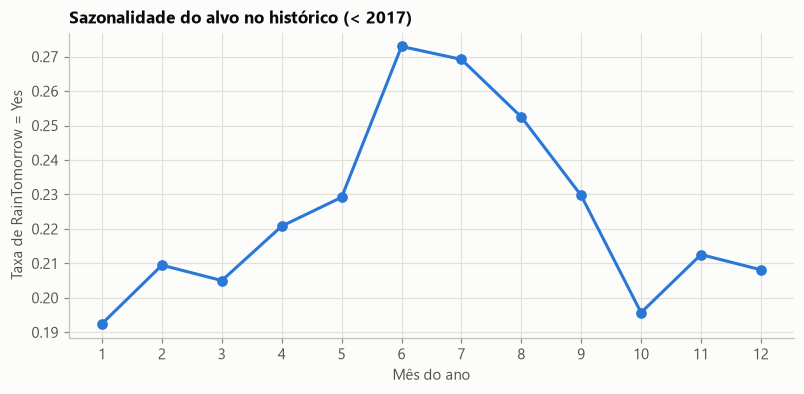

In [5]:
counts = dev["RainTomorrow"].value_counts(dropna=False)
labelled = dev["RainTomorrow"].dropna()
print(counts.to_string())
print(f"proporção Yes (entre rotuladas): {(labelled == 'Yes').mean():.4f} | No: {(labelled == 'No').mean():.4f}")

rate_year = dev.dropna(subset=["RainTomorrow"]).groupby(dev["Date"].dt.year)["RainTomorrow"].agg(
    n="size", taxa_yes=lambda s: (s == "Yes").mean())
rate_month = dev.dropna(subset=["RainTomorrow"]).groupby(dev["Date"].dt.month)["RainTomorrow"].agg(
    n="size", taxa_yes=lambda s: (s == "Yes").mean())
display(rate_year.T)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(rate_month.index, rate_month["taxa_yes"], color=plots.SERIES[0], marker="o", markersize=6)
ax.set(xticks=range(1, 13), xlabel="Mês do ano", ylabel="Taxa de RainTomorrow = Yes",
       title="Sazonalidade do alvo no histórico (< 2017)")
plt.show()

**Leitura.** A classe positiva é minoritária (cerca de 22,5% das linhas rotuladas). Uma regra que sempre responde "No" teria
accuracy ≈ 77,5% sem discriminar nada — por isso a accuracy não é usada para comparar modelos. A taxa de chuva é sazonal
(mínimo em janeiro, máximo em junho/julho), e o OOT só tem janeiro–junho.

### 1.3 Tipos, missing values e cardinalidade (histórico)

In [6]:
missing = dev.isna().mean().sort_values(ascending=False).rename("fração_missing")
display(missing.to_frame().T)

numeric_cols = config.NUMERIC_FEATURES
struct = (dev.groupby("Location")[numeric_cols + ["WindGustDir", "WindDir9am", "WindDir3pm"]]
          .agg(lambda s: s.isna().mean()) >= 0.95)
structural = struct.sum().loc[lambda s: s > 0].rename("nº de estações com >= 95% de missing")
display(structural.to_frame().T)

complete = dev.dropna(subset=["RainTomorrow"])[numeric_cols].notna().all(axis=1)
print(f"linhas rotuladas com as 16 numéricas completas: {complete.sum()} de {len(complete)} ({complete.mean():.1%})")

cardinality = {c: dev[c].nunique() for c in config.CATEGORICAL_FEATURES}
print("cardinalidade das categóricas:", cardinality)

,Sunshine,Evaporation,Cloud3pm,Cloud9am,Pressure9am,Pressure3pm,WindDir9am,WindGustDir,WindGustSpeed,Humidity3pm,WindDir3pm,RainTomorrow,Rainfall,RainToday,Temp3pm,WindSpeed3pm,Humidity9am,WindSpeed9am,Temp9am,MinTemp,MaxTemp,Date,Location
fração_missing,0.4636,0.4168,0.3993,0.3790,0.1036,0.1033,0.0728,0.0715,0.0711,0.0286,0.0279,0.0227,0.0227,0.0227,0.0225,0.0197,0.0185,0.0126,0.0125,0.0101,0.0086,0.0000,0.0000


,Evaporation,Sunshine,WindGustSpeed,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,WindGustDir
nº de estações com >= 95% de missing,17,19,2,4,4,12,12,2


linhas rotuladas com as 16 numéricas completas: 56325 de 133727 (42.1%)
cardinalidade das categóricas: {'Location': 49, 'WindGustDir': 16, 'WindDir9am': 16, 'WindDir3pm': 16, 'RainToday': 2}


**Leitura e decisões.**
- A ausência de `Sunshine`, `Evaporation`, `Cloud*` e `Pressure*` é **estrutural**: há estações que nunca medem essas variáveis.
  Descartar linhas incompletas jogaria fora mais da metade do histórico. Decisão: imputar pela **mediana do TRAIN** e testar,
  na CV, **indicadores de missing** (a variante é escolhida pelo protocolo da seção 8).
- `Location` (49 níveis) e as direções de vento (16 pontos cardeais) entram como categóricas com one-hot.

In [7]:
for t in ["9am", "3pm"]:
    d, v = dev[f"WindDir{t}"], dev[f"WindSpeed{t}"]
    print(f"WindDir{t}: {int(d.isna().sum())} NaN; destes, WindSpeed{t} == 0 em {int((d.isna() & v.eq(0)).sum())}; "
          f"linhas com WindSpeed{t} == 0: {int(v.eq(0).sum())} (todas sem direção: {bool(d[v.eq(0)].isna().all())})")

WindDir9am: 9957 NaN; destes, WindSpeed9am == 0 em 8185; linhas com WindSpeed9am == 0: 8185 (todas sem direção: True)
WindDir3pm: 3822 NaN; destes, WindSpeed3pm == 0 em 1067; linhas com WindSpeed3pm == 0: 1067 (todas sem direção: True)


**Direção do vento ausente ≈ calmaria.** Toda linha com vento de 0 km/h às 9h não tem direção registrada, e a maioria dos
`NaN` de `WindDir9am` vem daí. Imputar pela moda inventaria uma direção; a decisão é uma **categoria própria `"missing"`**
(imputação constante antes do one-hot).

### 1.4 Valores inconsistentes e outliers (histórico)

In [8]:
desc = dev[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).T
display(desc)
checks = {
    "MinTemp > MaxTemp": int((dev["MinTemp"] > dev["MaxTemp"]).sum()),
    "umidade fora de [0, 100]": int(((dev[["Humidity9am", "Humidity3pm"]] < 0) | (dev[["Humidity9am", "Humidity3pm"]] > 100)).any(axis=1).sum()),
    "valores negativos (chuva, evaporação, sol, vento)": int((dev[["Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm"]] < 0).any(axis=1).sum()),
    "Cloud fora de [0, 8] oitavos": int(((dev[["Cloud9am", "Cloud3pm"]] > 8)).any(axis=1).sum()),
    "Rainfall == 0 (fração)": round(float(dev["Rainfall"].eq(0).mean()), 4),
    "Evaporation > 60 mm": int((dev["Evaporation"] > 60).sum()),
}
display(pd.Series(checks, name="verificação").to_frame())

,count,mean,std,min,1%,50%,99%,max
MinTemp,135458.0000,12.0985,6.3749,-8.5000,-1.9000,11.9000,25.7000,33.9000
MaxTemp,135657.0000,23.1074,7.1080,-4.8000,8.9000,22.5000,40.0000,48.1000
Rainfall,133728.0000,2.3534,8.4564,0.0000,0.0000,0.0000,37.2000,371.0000
Evaporation,79800.0000,5.4426,4.1677,0.0000,0.4000,4.6000,18.2000,145.0000
Sunshine,73394.0000,7.6092,3.7856,0.0000,0.0000,8.4000,13.4000,14.5000
WindGustSpeed,127114.0000,40.1929,13.6489,6.0000,15.0000,39.0000,81.0000,135.0000
WindSpeed9am,135119.0000,14.1156,8.9467,0.0000,0.0000,13.0000,39.0000,87.0000
WindSpeed3pm,134136.0000,18.7508,8.8370,0.0000,2.0000,19.0000,43.0000,87.0000
Humidity9am,134312.0000,68.7320,19.0382,0.0000,17.0000,70.0000,100.0000,100.0000
Humidity3pm,132924.0000,51.5212,20.7927,0.0000,8.0000,52.0000,98.0000,100.0000


,verificação
MinTemp > MaxTemp,0.0000
"umidade fora de [0, 100]",0.0000
"valores negativos (chuva, evaporação, sol, vento)",0.0000
"Cloud fora de [0, 8] oitavos",3.0000
Rainfall == 0 (fração),0.6247
Evaporation > 60 mm,21.0000


**Leitura.** Não há inconsistências lógicas. `Rainfall` e `Evaporation` têm cauda longa (muitos zeros; máximos de 371 mm e 145 mm).
As notas do BoM avisam que, após dias sem medição, chuva e evaporação podem vir **acumuladas de vários dias**, o que explica parte
dos extremos. Não removo outliers (seriam decisões sem critério externo); a variante `log1p` para essas duas variáveis é avaliada
na CV. Três leituras de nuvem valem 9 (fora da escala 0–8) e são mantidas: o efeito é desprezível.

### 1.5 O que exatamente é o alvo — e que informação existe no momento da previsão

Verificação direta nos dados (histórico): `RainTomorrow` do dia *t* é o `RainToday` do dia *t+1* da mesma estação, e `RainToday`
é `Rainfall > 1 mm`.

In [9]:
s = dev.sort_values(["Location", "Date"])
nxt = s.groupby("Location")[["Date", "RainToday", "Temp9am"]].shift(-1)
consecutive = (nxt["Date"] - s["Date"]).dt.days.eq(1)
m = consecutive & s["RainTomorrow"].notna() & nxt["RainToday"].notna()
print(f"RainTomorrow(t) == RainToday(t+1): {(s.loc[m, 'RainTomorrow'] == nxt.loc[m, 'RainToday']).mean():.5f} (n = {int(m.sum())})")
rt = dev.dropna(subset=["Rainfall", "RainToday"])
print(f"RainToday == (Rainfall > 1.0): {((rt['Rainfall'] > 1.0) == rt['RainToday'].eq('Yes')).mean():.5f}; "
      f"linhas com Rainfall == 1.0 marcadas 'No': {int(rt.loc[rt['Rainfall'] == 1.0, 'RainToday'].eq('No').sum())}")
windows = pd.Series(config.FEATURE_WINDOWS, name="janela de medição (BoM)").to_frame()
display(windows)

RainTomorrow(t) == RainToday(t+1): 1.00000 (n = 133546)
RainToday == (Rainfall > 1.0): 1.00000; linhas com Rainfall == 1.0 marcadas 'No': 1683


,janela de medição (BoM)
MinTemp,24h até 09:00 de t
Rainfall,24h até 09:00 de t
RainToday,24h até 09:00 de t
Evaporation,24h até 09:00 de t
Temp9am,instante 09:00 de t
Humidity9am,instante 09:00 de t
Cloud9am,instante 09:00 de t
Pressure9am,instante 09:00 de t
WindDir9am,média 10 min antes de 09:00 de t
WindSpeed9am,média 10 min antes de 09:00 de t


**Pergunta de revisão: qual informação está disponível no momento em que queremos prever se choverá amanhã?**

Pelo cartão do dataset, a chuva de um dia é medida *"nas 24 horas até as 9h"*. Logo o alvo de *t* é a chuva **entre 09:00 de *t* e
09:00 de *t+1***. Pelas notas do BoM (tabela acima): `MinTemp`, `Rainfall`, `RainToday`, `Evaporation` e as leituras das 9h fecham
**antes** dessa janela; as leituras das 15h, `Sunshine` e `WindGust*` (até a meia-noite) caem **dentro** dela; `MaxTemp` é o
máximo das 24h **a partir** das 9h, isto é, a **mesma janela do alvo**, fechando só às 09:00 de *t+1*.

Consequências para o desenho do experimento:
- o modelo é tratado como uma previsão **emitida ao fim do dia *t*** (00:00 de *t+1*), com as observações do dia;
- **`MaxTemp` fica fora do modelo final** (20 features): é a única variável cuja janela termina *depois* desse momento
  (às 09:00 de *t+1*, junto com o alvo), portanto seria informação formalmente futura;
- parte da janela do alvo (09:00–24:00 de *t*) já transcorreu no momento da previsão: o problema é parcialmente *nowcasting*;
- a análise de sensibilidade da seção 8 compara o conjunto final com as 21 features (com `MaxTemp`) e com um conjunto restrito
  ao que existe às 09:00 de *t*.

A checagem abaixo confirma empiricamente a janela de `MaxTemp`: se ela fosse o máximo do dia civil, a temperatura das 9h do dia
seguinte ultrapassaria o `MaxTemp` de vez em quando (como `MinTemp` ultrapassa a leitura das 15h do mesmo dia).

In [10]:
tol = 0.5
ok_next = consecutive & nxt["Temp9am"].notna() & s["MaxTemp"].notna()
print(f"Temp9am(t+1) > MaxTemp(t) + {tol}: {(nxt.loc[ok_next, 'Temp9am'] > s.loc[ok_next, 'MaxTemp'] + tol).mean():.4%} (n = {int(ok_next.sum())})")
ok_same = s["MinTemp"].notna() & s["Temp3pm"].notna()
print(f"MinTemp(t) > Temp3pm(t) + {tol}:     {(s.loc[ok_same, 'MinTemp'] > s.loc[ok_same, 'Temp3pm'] + tol).mean():.4%} (n = {int(ok_same.sum())})")

Temp9am(t+1) > MaxTemp(t) + 0.5: 0.0037% (n = 134775)
MinTemp(t) > Temp3pm(t) + 0.5:     0.5842% (n = 133346)


## 2. Classificação binária — vocabulário aplicado ao projeto

| Conceito | Neste projeto |
|---|---|
| **Classe positiva / negativa** | Positiva = `RainTomorrow = Yes` (chuva > 1 mm entre 09:00 de *t* e 09:00 de *t+1*). É o evento que se quer antecipar e a classe minoritária; precision, recall e PR-AUC são definidas em torno dela. |
| **Score / probabilidade** | `predict_proba` devolve `[P(No), P(Yes)]` por linha; o score é a coluna `P(Yes)`. É uma estimativa de P(chuva \| observações do dia); a leitura como frequência depende da calibração (verificada na seção 9). |
| **Threshold** | A decisão Yes/No surge ao comparar o score com um corte *t* (Yes se score ≥ *t*). **Neste projeto nenhum corte é escolhido**; `predict.py` devolve a probabilidade. |
| **TP / FP / TN / FN** | TP: previu chuva e choveu. FP: previu chuva e não choveu (alarme falso). TN: previu tempo seco e não choveu. FN: previu tempo seco e choveu (a pessoa é pega desprevenida). |
| **Accuracy** | (TP + TN) / N. Engana em classe desbalanceada: responder sempre "No" acerta ~77,5% do histórico sem identificar nenhum dia de chuva. |
| **Precision** | TP / (TP + FP): dos dias em que o modelo avisou chuva, quantos choveram. |
| **Recall / Sensitivity** | TP / (TP + FN): dos dias que choveram, quantos o modelo avisou. |
| **Specificity** | TN / (TN + FP): dos dias secos, quantos o modelo reconheceu como secos. |
| **F1** | Média harmônica de precision e recall; como ambas dependem do corte, F1 também depende. |
| **ROC-AUC** | Probabilidade de um dia chuvoso sorteado receber score maior que um dia seco sorteado; resume TPR × FPR em todos os cortes. 0,5 = ordenação aleatória. Não depende da prevalência. |
| **PR-AUC** | Aqui calculada como *Average Precision*: precision média ao longo dos níveis de recall. O patamar de um modelo sem habilidade é a **prevalência**, então ela muda quando a taxa de chuva muda, mesmo que a ordenação seja a mesma. Mais informativa quando a classe positiva é rara, porque ignora os TN. |
| **KS** | Maior distância vertical entre as distribuições acumuladas dos scores de dias chuvosos e secos, igual a max(TPR − FPR). Mede separação no melhor ponto de corte, sem fixar um corte operacional. |

ROC-AUC, PR-AUC e KS usam apenas a **ordenação dos scores**, por isso avaliam discriminação sem threshold. São as três métricas de
comparação do projeto; as dependentes de threshold aparecem só para ilustração (seção 9).

## 3. Regressão Logística em alto nível

- **Por que "regressão" se é classificação?** O modelo regride o *log-odds* da classe positiva como função linear das features,
  `log(p / (1 − p)) = b0 + b1·x1 + … + bk·xk`. A saída é uma probabilidade; vira classe só quando se aplica um threshold.
- **Sigmoid.** `p = 1 / (1 + e^(−z))` leva qualquer `z` real para (0, 1). Como é ajustada por máxima verossimilhança da Bernoulli,
  a saída tem interpretação probabilística.
- **Coeficientes e intercepto.** `bj` é a variação no log-odds por unidade de `xj` (aqui, por desvio-padrão, pois as numéricas são
  padronizadas); `exp(bj)` é a razão de chances. O intercepto é o log-odds quando todas as features valem zero (as médias do TRAIN,
  após a padronização).
- **Regularização.** Penaliza a magnitude dos coeficientes para reduzir variância. **L2** encolhe todos suavemente; **L1** pode zerar
  alguns (seleção de variáveis). No scikit-learn, **`C` é o inverso da força**: C menor → mais regularização. Na versão 1.9 o
  parâmetro `penalty` está obsoleto; o tipo é dado por `l1_ratio` (0 = L2, 1 = L1). Solvers: `lbfgs` para L2, `saga` para L1.
- **`class_weight`.** Dá mais peso aos erros de uma classe; `"balanced"` usa pesos inversamente proporcionais às frequências. Pode
  ajudar quando a classe positiva é rara e o objetivo é recall, mas **desloca as probabilidades para cima** (elas deixam de refletir a
  prevalência real), e a ordenação — o que ROC-AUC, PR-AUC e KS medem — muda pouco. Por isso entra na grade, mas `None` tem
  preferência no desempate.
- **StandardScaler.** A penalização trata todos os coeficientes igualmente; sem escala comparável, uma variável em hPa (~1000) e
  outra em oitavos (0–8) seriam penalizadas de forma desigual. Padronizar também acelera a convergência e torna os coeficientes comparáveis.

## 4. Out-of-Time: separado antes de qualquer fit

A separação já aconteceu na seção 1.1: `split_development_oot` cortou em `Date < 2017-01-01` (desenvolvimento) e `Date >= 2017-01-01`
(OOT), e o OOT foi descartado da memória. No código, `load_development_data` descarta o OOT logo após a leitura e `assert_no_oot`
protege toda rotina de ajuste (`split_train_test`, `evaluate_candidates`, `run_model_selection`). `scripts/train.py` nunca lê 2017
(há teste automatizado verificando isso).

O OOT responde a uma pergunta diferente do teste aleatório: **"o modelo já definido funciona num período posterior ao que o gerou?"**
O teste aleatório mistura dias de todos os anos e mede generalização dentro do mesmo período.

## 5. Split treino/teste no histórico (80/20, estratificado, `random_state=42`)

**Escolha 80/20.** Com ~134 mil linhas rotuladas, 20% dá um teste com cerca de 6 mil dias de chuva — suficiente para métricas com
intervalos estreitos — e deixa mais dados para o treino. O ajuste de hiperparâmetros é feito por CV **dentro do TRAIN**, então o
TEST não é usado para escolher nada. `stratify=y` preserva a taxa de chuva nos dois lados. Linhas sem `RainTomorrow` (dia seguinte
sem medição) são removidas antes do split.

In [11]:
data = load_train_test()
train, test = data["train"], data["test"]
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)
split_summary = pd.DataFrame({
    "linhas": [data["n_dev_rows"], data["n_dropped_missing_target"], len(train), len(test)],
}, index=["histórico < 2017", "removidas (sem target)", "TRAIN", "TEST"])
display(split_summary.T)
print(f"prevalência TRAIN {y_train.mean():.4f} | TEST {y_test.mean():.4f}")
assert train["Date"].max() < pd.Timestamp(config.OOT_START) and test["Date"].max() < pd.Timestamp(config.OOT_START)
assert not set(train.index) & set(test.index)

,histórico < 2017,removidas (sem target),TRAIN,TEST
linhas,136837,3110,106981,26746


prevalência TRAIN 0.2252 | TEST 0.2252


## 6. Data leakage — onde poderia acontecer e como foi evitado

| Tipo | Risco concreto neste dataset | Proteção |
|---|---|---|
| Informação futura | `RainTomorrow(t) = RainToday(t+1)`: qualquer *lead* de chuva é o próprio alvo. `RISK_MM` (chuva do dia seguinte) existe em versões antigas. `MaxTemp` fecha às 09:00 de *t+1*. | Só colunas brutas; nenhuma feature usa linhas futuras; `RISK_MM` não existe nesta versão e seria ignorado (`remainder="drop"`). `MaxTemp` excluída do modelo final (seção 1.5); aparece só na análise de sensibilidade. |
| Preprocessing | Medianas, médias/desvios ou categorias calculados com TEST ou OOT. | Tudo dentro de um único `Pipeline`, ajustado só no TRAIN (e, na CV, só no fold de treino). Testes conferem que as estatísticas do modelo salvo são as do TRAIN. |
| Contaminação do OOT | Olhar 2017, mudar features/C e reavaliar 2017. | Protocolo de seleção pré-registrado em `config.py`; modelo congelado com hash antes de abrir 2017; `evaluate.py` não chama `fit`. |
| Feature temporal | Ano como feature (extrapola para 2017), agregados por estação com o período inteiro. | Só dia do ano (seno/cosseno); nenhum agregado; nenhum target encoding. |
| Split aleatório | Dias vizinhos da mesma estação são muito parecidos e caem em TRAIN e TEST → teste otimista. | Não é vazamento proibido, mas limita o que o TEST responde; por isso o OOT existe e é a avaliação temporal. |

## 7. Preprocessing reproduzível

**Features do modelo final (20 brutas + 2 derivadas de `Date`):** 15 numéricas (`MinTemp`, `Rainfall`, `Evaporation`, `Sunshine`,
`WindGustSpeed`, `WindSpeed9am`, `WindSpeed3pm`, `Humidity9am`, `Humidity3pm`, `Pressure9am`, `Pressure3pm`, `Cloud9am`, `Cloud3pm`,
`Temp9am`, `Temp3pm`), 5 categóricas (`Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`) e seno/cosseno do dia do ano.

`ColumnTransformer` + `Pipeline`, ajustados somente no TRAIN:

- numéricas → [log1p em `Rainfall`/`Evaporation`, se a variante for escolhida] → `SimpleImputer(median)` [+ indicadores de missing] → `StandardScaler`
- categóricas (`Location`, direções do vento, `RainToday`) → `SimpleImputer(constant="missing")` → `OneHotEncoder(handle_unknown="ignore")`
- `Date` → seno e cosseno do dia do ano (sem ano)
- qualquer outra coluna é descartada (`remainder="drop"`)

In [12]:
display(build_pipeline(feature_set=config.FINAL_FEATURE_SET, preprocessing="indicators_log"))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.

## 8. Baseline e ajuste da Regressão Logística

### 8.1 Baseline
Configuração simples, registrada no TEST antes de qualquer ajuste: preprocessing `base` (mediana + scaler; categorias com
`"missing"` + one-hot) e `LogisticRegression` padrão (C = 1, L2, `lbfgs`).

In [13]:
frozen_metrics = read_json(config.METRICS_PATH)
frozen_meta = read_json(config.METADATA_PATH)

baseline_params = {"feature_set": config.FINAL_FEATURE_SET, "preprocessing": config.BASELINE_PREPROCESSING,
                   **config.BASELINE_MODEL_PARAMS}
baseline = build_pipeline(**baseline_params).fit(X_train, y_train)
baseline_test = evaluate_scores(y_test, baseline.predict_proba(X_test)[:, 1])
display(pd.DataFrame([baseline_test])[["n", "prevalence", "roc_auc", "roc_auc_ci_low", "roc_auc_ci_high",
                                       "pr_auc", "pr_auc_ci_low", "pr_auc_ci_high", "ks", "ks_ci_low", "ks_ci_high"]])
for m in ("roc_auc", "pr_auc", "ks"):
    assert abs(baseline_test[m] - frozen_metrics["baseline"]["test"][m]) < 1e-12  # mesmo valor registrado por train.py

,n,prevalence,roc_auc,roc_auc_ci_low,roc_auc_ci_high,pr_auc,pr_auc_ci_low,pr_auc_ci_high,ks,ks_ci_low,ks_ci_high
0,26746,0.2252,0.8751,0.8701,0.8802,0.7126,0.7016,0.7236,0.5821,0.5717,0.5947


### 8.2 Protocolo de seleção (pré-registrado em `src/config.py`, somente TRAIN)

- **Validação:** `StratifiedKFold(5, shuffle=True, random_state=42)` dentro do TRAIN; o pipeline inteiro é reajustado em cada fold.
- **Métrica de seleção: ROC-AUC médio.** A pergunta central é sobre *discriminar* chuva de não chuva; a ROC-AUC mede exatamente a
  ordenação e não depende da prevalência. PR-AUC e KS são registradas para todos os candidatos.
- **Regra de 1 erro-padrão:** entre os candidatos cuja média fica a até 1 EP (desvio-padrão entre folds / √5) do melhor, escolhe-se o
  primeiro na ordem de preferência — o mais simples/regularizado. Diferenças menores que o ruído entre folds não justificam mais
  complexidade.
- **Estágio 1 — preprocessing** (com a LR baseline): `base` → `indicators` (indicadores de missing) → `indicators_log` (+ log1p em
  `Rainfall`/`Evaporation`).
- **Estágio 2 — hiperparâmetros:** C ∈ {0,001; 0,01; 0,1; 1; 10; 100} × penalty {L2, L1} × `class_weight` {None, balanced}.
  Ordem de preferência: `None` antes de `balanced` (mantém a probabilidade na escala da prevalência observada), menor C antes, L2 antes de L1.

A célula abaixo reexecuta toda a seleção (≈ 10 min, 135 ajustes) e confere que chega à mesma escolha congelada por `train.py`.

In [14]:
selection = run_model_selection(X_train, y_train, feature_set=config.FINAL_FEATURE_SET)
cv_results = selection["cv_results"]
selected = selection["selected_params"]
cols = ["stage", "preprocessing", "C", "penalty", "class_weight", "roc_auc_mean", "roc_auc_se", "pr_auc_mean",
        "pr_auc_se", "ks_mean", "ks_se", "selected"]
display(cv_results[cols])
print("selecionado:", selected)

frozen_cv = pd.read_csv(config.CV_RESULTS_PATH)
np.testing.assert_allclose(cv_results["roc_auc_mean"], frozen_cv["roc_auc_mean"], rtol=0, atol=1e-12)
assert selected["preprocessing"] == frozen_meta["model"]["preprocessing_variant"]
assert selected["C"] == frozen_meta["model"]["C"] and selected["l1_ratio"] == frozen_meta["model"]["l1_ratio"]
assert selected["class_weight"] == frozen_meta["model"]["class_weight"]

,stage,preprocessing,C,penalty,class_weight,roc_auc_mean,roc_auc_se,pr_auc_mean,pr_auc_se,ks_mean,ks_se,selected
0,1_preprocessing,base,1.0000,l2,None,0.8731,0.0008,0.7063,0.0024,0.5814,0.0018,False
1,1_preprocessing,indicators,1.0000,l2,None,0.8743,0.0007,0.7084,0.0024,0.5833,0.0017,True
2,1_preprocessing,indicators_log,1.0000,l2,None,0.8749,0.0008,0.7101,0.0023,0.5847,0.0016,False
3,2_hyperparameters,indicators,0.0010,l2,NaN,0.8676,0.0008,0.6929,0.0023,0.5694,0.0022,False
4,2_hyperparameters,indicators,0.0010,l1,NaN,0.8580,0.0008,0.6786,0.0023,0.5509,0.0025,False
5,2_hyperparameters,indicators,0.0100,l2,NaN,0.8733,0.0007,0.7053,0.0023,0.5804,0.0015,False
6,2_hyperparameters,indicators,0.0100,l1,NaN,0.8682,0.0005,0.6954,0.0021,0.5703,0.0019,False
7,2_hyperparameters,indicators,0.1000,l2,NaN,0.8742,0.0007,0.7083,0.0023,0.5830,0.0019,True
8,2_hyperparameters,indicators,0.1000,l1,NaN,0.8742,0.0007,0.7081,0.0023,0.5826,0.0019,False
9,2_hyperparameters,indicators,1.0000,l2,NaN,0.8743,0.0007,0.7084,0.0024,0.5833,0.0017,False


selecionado: {'feature_set': 'full_without_maxtemp', 'preprocessing': 'indicators', 'C': 0.1, 'l1_ratio': 0.0, 'class_weight': None}


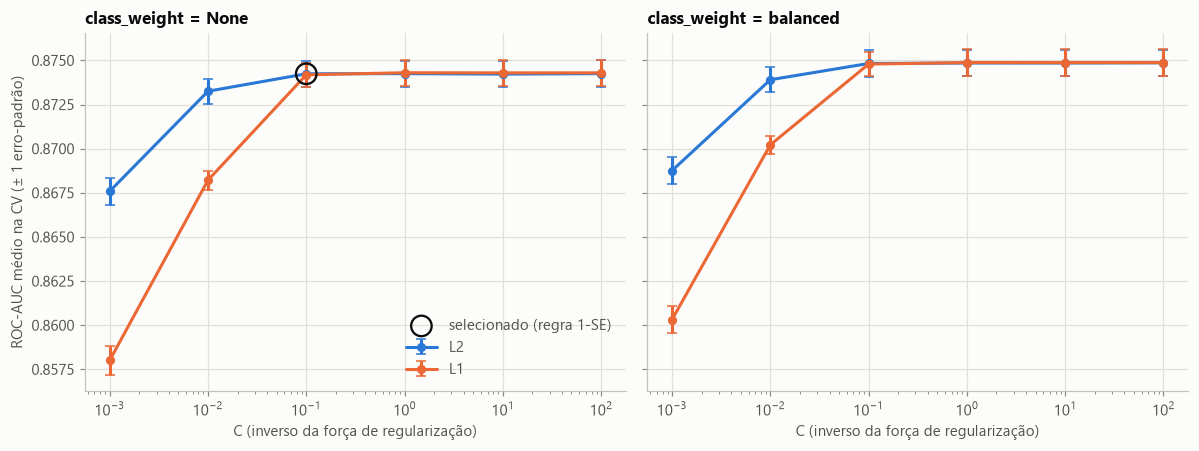

In [15]:
plots.plot_cv_path(cv_results)
plt.show()

**Leitura da seleção (CV no TRAIN, 20 features).**
- **Estágio 1.** Os indicadores de missing elevam o ROC-AUC médio de 0,8731 (`base`) para 0,8743, ganho maior que 1 erro-padrão
  (≈ 0,0008). O `log1p` em `Rainfall`/`Evaporation` acrescenta mais 0,0006 (0,8749), dentro de 1 EP do melhor; pela regra, fica a
  variante mais simples, `indicators`.
- **Estágio 2.** A partir de C = 0,1 o ROC-AUC é praticamente constante (0,8742–0,8749 em todas as combinações): com ~107 mil linhas
  e 135 colunas, a regularização quase não altera o ajuste. Só a regularização forte (C ≤ 0,01) piora — e piora mais com L1, que zera
  coeficientes.
- **`class_weight`.** Com `"balanced"` o ROC-AUC é ~0,0006 maior e a PR-AUC ~0,0035 menor que com `None` no mesmo C; a diferença de
  ROC-AUC fica dentro de 1 EP e a ordem de preferência escolhe `None`, que mantém as probabilidades na escala da prevalência real.
- **Escolha congelada:** `indicators`, C = 0,1, L2 (`lbfgs`), `class_weight=None` — a configuração mais regularizada entre as
  indistinguíveis da melhor. ROC-AUC na CV: 0,8742 (EP 0,0007).

### 8.3 Análise de sensibilidade: informação disponível até as 09:00 × ao fim do dia

Mesma configuração congelada; só muda o conjunto de features. **É informativa** — não alterou a escolha do modelo e não é avaliada
no OOT. Conjuntos: `full_without_maxtemp` (**modelo final**, 20 features, tudo fechado até o fim do dia *t*), `full` (21 features,
inclui `MaxTemp`, cuja janela fecha às 09:00 de *t+1*) e `morning` (apenas o que existe às 09:00 de *t*: `MinTemp`, `Rainfall`,
`RainToday`, `Evaporation`, leituras das 9h e `Location`).

In [16]:
sensitivity = pd.read_csv(config.SENSITIVITY_PATH)
base_params = {k: v for k, v in selected.items() if k != "feature_set"}
recheck = evaluate_candidates([{"feature_set": fs, **base_params} for fs in sensitivity["feature_set"]], X_train, y_train)
np.testing.assert_allclose(recheck["roc_auc_mean"], sensitivity["cv_roc_auc_mean"], rtol=0, atol=1e-12)
display(sensitivity.drop(columns=["features"]))

,feature_set,is_final_model,n_raw_features,cv_roc_auc_mean,cv_roc_auc_se,cv_pr_auc_mean,cv_pr_auc_se,cv_ks_mean,cv_ks_se,test_roc_auc,test_pr_auc,test_ks
0,full,False,21,0.8744,0.0007,0.7089,0.0022,0.5830,0.0017,0.8756,0.7135,0.5838
1,full_without_maxtemp,True,20,0.8742,0.0007,0.7083,0.0023,0.5830,0.0019,0.8757,0.7138,0.5839
2,morning,False,11,0.8117,0.0013,0.5684,0.0025,0.4731,0.0037,0.8159,0.5808,0.4760


**Leitura.**
- **Retirar `MaxTemp` não tem custo mensurável:** ROC-AUC na CV 0,8742 (20 features) × 0,8744 (21), diferença de 0,0002 ≈ 0,3 EP;
  no TEST, 0,8757 × 0,8756. A exclusão, decidida por validade temporal (seção 1.5), não sacrifica desempenho — as leituras da tarde
  já carregam essa informação.
- **Restringir ao que existe às 09:00 derruba o desempenho:** ROC-AUC 0,8117 (−0,063), PR-AUC 0,568 (−0,140), KS 0,473 (−0,110) na
  CV. Boa parte da capacidade do modelo vem de observações da tarde (umidade e pressão das 15h, rajada, sol), que caem dentro da
  janela do alvo. O problema, como definido no dataset, é em parte *nowcasting*: quem precisasse decidir às 9h teria um modelo
  bem pior.
- Estes números são de CV no TRAIN e do TEST. Nenhum conjunto alternativo é avaliado no OOT.

## 9. Modelo final e avaliação no TEST (registrada antes de abrir o OOT)

O modelo final é o pipeline selecionado ajustado em todo o TRAIN. Carrego o artefato congelado (hash verificado) e confiro que um
reajuste aqui no notebook produz exatamente os mesmos coeficientes.

In [17]:
model, meta = load_frozen_model()
print("modelo congelado em", meta["frozen_at_utc"], "| sha256", meta["model_sha256"][:16], "...")
refit = build_pipeline(**selected).fit(X_train, y_train)
np.testing.assert_allclose(refit.named_steps["model"].coef_, model.named_steps["model"].coef_, rtol=0, atol=1e-10)

s_train = model.predict_proba(X_train)[:, 1]
s_test = model.predict_proba(X_test)[:, 1]
train_m = discrimination_metrics(y_train, s_train)
test_m = evaluate_scores(y_test, s_test)
for m in ("roc_auc", "pr_auc", "ks"):
    assert abs(test_m[m] - frozen_metrics["test"][m]) < 1e-12
persist_test = discrimination_metrics(y_test, persistence_score(X_test))
summary = pd.DataFrame({
    "TRAIN (in-sample)": {m: train_m[m] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST": {m: test_m[m] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST IC95% inf": {m: test_m[f"{m}_ci_low"] for m in ("roc_auc", "pr_auc", "ks")},
    "TEST IC95% sup": {m: test_m[f"{m}_ci_high"] for m in ("roc_auc", "pr_auc", "ks")},
    "baseline (TEST)": {m: baseline_test[m] for m in ("roc_auc", "pr_auc", "ks")},
    "persistência RainToday (TEST)": {m: persist_test[m] for m in ("roc_auc", "pr_auc", "ks")},
    "sem habilidade": {"roc_auc": 0.5, "pr_auc": float(y_test.mean()), "ks": 0.0},
}).T
display(summary)

modelo congelado em 2026-09-28T22:41:09+00:00 | sha256 b274388f39b24a33 ...


,roc_auc,pr_auc,ks
TRAIN (in-sample),0.8754,0.7104,0.5846
TEST,0.8757,0.7138,0.5839
TEST IC95% inf,0.8707,0.7026,0.5739
TEST IC95% sup,0.8807,0.7254,0.5970
baseline (TEST),0.8751,0.7126,0.5821
persistência RainToday (TEST),0.6608,0.3410,0.3220
sem habilidade,0.5000,0.2252,0.0000


**Leitura (TEST: 26.746 dias, prevalência 0,2252).**
- **ROC-AUC 0,8757** [IC95% 0,8707–0,8807]: sorteando um dia chuvoso e um seco, o modelo dá score maior ao chuvoso em cerca de
  87,6% dos pares.
- **PR-AUC 0,7138** [0,7026–0,7254], contra 0,2252 de um classificador sem habilidade (a prevalência).
- **KS 0,5839** [0,5739–0,5970]: no melhor ponto de corte, as distribuições acumuladas de scores de dias secos e chuvosos ficam
  58,4 pontos percentuais distantes.
- **TRAIN in-sample (0,8754 / 0,7104 / 0,5846) ≈ TEST:** não há sinal de sobreajuste, o esperado para um modelo linear regularizado
  com ~107 mil linhas. Isso também mostra o limite do TEST aleatório: ele mede o desempenho dentro do mesmo período; a pergunta
  temporal é respondida pelo OOT.
- **Sobre o baseline** (0,8751 / 0,7126 / 0,5821), a seleção acrescenta pouco (+0,0006 de ROC-AUC, dentro do IC): o desempenho vem
  das features, não do ajuste fino de hiperparâmetros.
- **Persistência** ("amanhã chove se choveu hoje"): ROC-AUC 0,6608 e PR-AUC 0,3410 — o modelo acrescenta muito sobre ela.

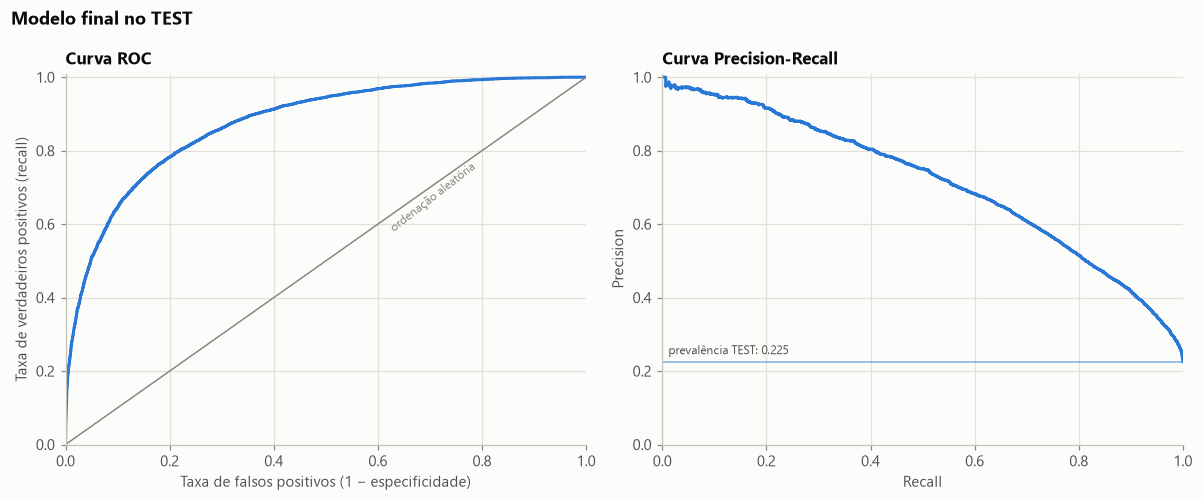

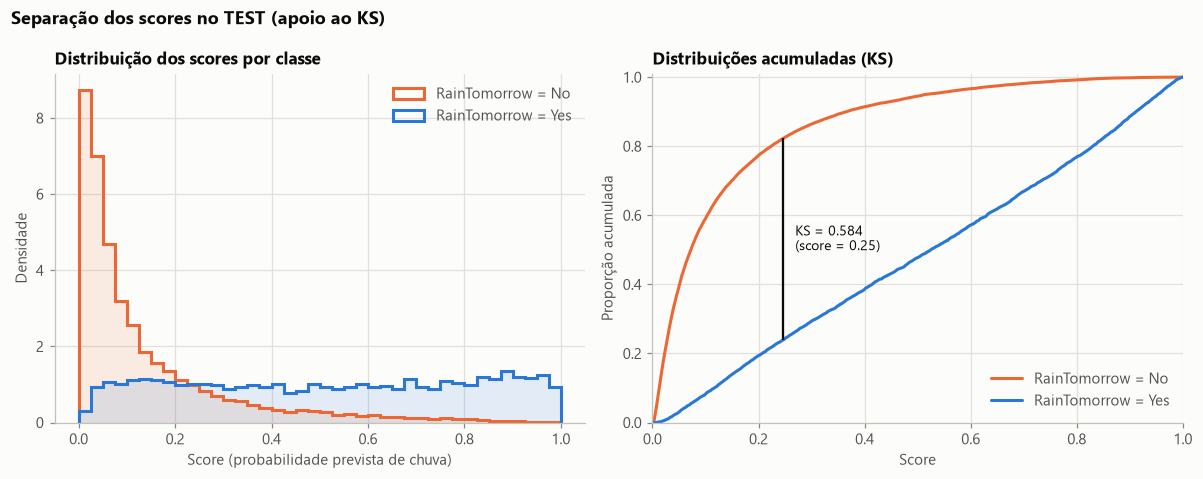

In [18]:
plots.plot_roc_pr({"TEST": (y_test, s_test)}, title="Modelo final no TEST")
plt.show()
plots.plot_score_distributions(y_test, s_test, title="Separação dos scores no TEST (apoio ao KS)")
plt.show()

### 9.1 Threshold: por que ele muda a matriz de confusão (ilustração, nenhum corte é escolhido)

In [19]:
thr = pd.DataFrame([threshold_metrics(y_test, s_test, t) for t in config.ILLUSTRATIVE_THRESHOLDS]).set_index("threshold")
display(thr)
always_no = threshold_metrics(y_test, np.zeros_like(s_test), 0.5)
print(f"Referência 'sempre No': accuracy {always_no['accuracy']:.4f}, recall {always_no['recall']:.4f}")

,tp,fp,tn,fn,accuracy,precision,recall,specificity,f1,predicted_positive_rate
threshold,,,,,,,,,,
0.3000,4257,2814,17909,1766,0.8288,0.6020,0.7068,0.8642,0.6502,0.2644
0.5000,3148,1140,19583,2875,0.8499,0.7341,0.5227,0.9450,0.6106,0.1603
0.7000,1992,380,20343,4031,0.8351,0.8398,0.3307,0.9817,0.4746,0.0887


Referência 'sempre No': accuracy 0.7748, recall 0.0000


**Leitura (ilustrativa — nenhum corte é escolhido).**
- **Em 0,5:** precision 0,734, recall 0,523, specificity 0,945, F1 0,611, accuracy 0,850. O modelo avisa chuva em 16,0% dos dias e
  acerta 73% desses avisos, mas deixa passar quase metade dos dias chuvosos (2.875 FN).
- **Em 0,3:** o recall sobe para 0,707 (FN cai para 1.766) ao custo de mais alarmes falsos (FP de 1.140 para 2.814; precision 0,602).
  **Em 0,7:** o contrário (precision 0,840, recall 0,331).
- A **accuracy** quase não se move (0,829–0,850) e fica perto dos 0,775 de responder sempre "No": ela esconde justamente a troca
  entre FP e FN.
- O melhor corte depende do custo relativo de um FP (levar guarda-chuva à toa) e de um FN (tomar chuva). **0,5 não tem nada de
  especial:** não reflete esses custos, e com prevalência de 22,5% só 16% dos dias recebem score ≥ 0,5; a maior separação entre as
  classes (KS) ocorre por volta de 0,25. O projeto não escolhe o corte; `predict.py` entrega a probabilidade.

### 9.2 A probabilidade é interpretável como frequência? (diagnóstico de calibração no TEST)

,n,score_medio,taxa_observada
decil,,,
1,2675,0.0092,0.0056
2,2675,0.0222,0.0179
3,2674,0.0379,0.0378
4,2675,0.0590,0.0613
5,2674,0.0899,0.0868
6,2675,0.1363,0.1458
7,2674,0.2083,0.2057
8,2675,0.3252,0.3305
9,2674,0.5305,0.5340


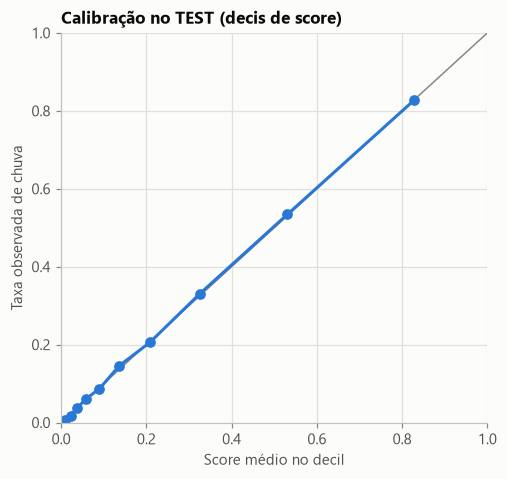

In [20]:
calib = pd.DataFrame({"score": s_test, "y": y_test})
calib["decil"] = pd.qcut(calib["score"], 10, labels=False, duplicates="drop") + 1
calib_table = calib.groupby("decil").agg(n=("y", "size"), score_medio=("score", "mean"), taxa_observada=("y", "mean"))
display(calib_table)
fig, ax = plt.subplots(figsize=(5, 4.6))
ax.plot([0, 1], [0, 1], color=plots.MUTED, linewidth=1)
ax.plot(calib_table["score_medio"], calib_table["taxa_observada"], color=plots.SERIES[0], marker="o", markersize=6)
ax.set(xlabel="Score médio no decil", ylabel="Taxa observada de chuva", title="Calibração no TEST (decis de score)",
       xlim=(0, 1), ylim=(0, 1))
plt.show()

**Leitura.** Em todos os decis o score médio fica próximo da taxa observada (decil 10: 0,827 previsto × 0,827 observado;
decil 6: 0,136 × 0,146), e o score médio no TEST (0,2246) é praticamente a prevalência (0,2252). No histórico, a saída pode ser
lida como probabilidade — consequência de `class_weight=None` (com `"balanced"` os scores seriam deslocados para cima). Calibração
não é métrica de comparação do projeto e não entrou em nenhuma escolha.

### 9.3 Coeficientes

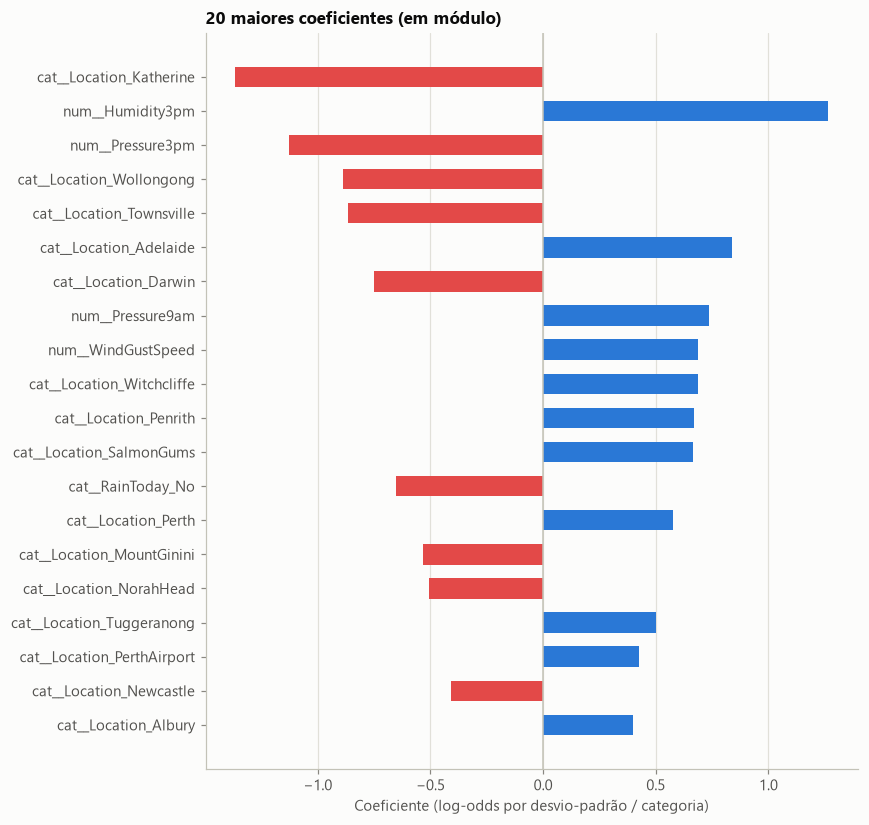

,feature,coefficient,abs_coefficient
0,cat__Location_Katherine,-1.3658,1.3658
1,num__Humidity3pm,1.2658,1.2658
2,num__Pressure3pm,-1.1276,1.1276
3,cat__Location_Wollongong,-0.8877,0.8877
4,cat__Location_Townsville,-0.8652,0.8652
5,cat__Location_Adelaide,0.8396,0.8396
6,cat__Location_Darwin,-0.7518,0.7518
7,num__Pressure9am,0.7352,0.7352
8,num__WindGustSpeed,0.6890,0.6890
9,cat__Location_Witchcliffe,0.6886,0.6886


In [21]:
coefs = coefficient_table(model)
plots.plot_coefficients(coefs, top_n=20)
plt.show()
display(coefs.head(12))

**Leitura (log-odds; numéricas por desvio-padrão do TRAIN).**
- **Maiores efeitos numéricos:** `Humidity3pm` (+1,27: tarde úmida aumenta a chance de chuva), `Pressure3pm` (−1,13) e `Pressure9am`
  (+0,74). Os sinais opostos das duas pressões indicam que o modelo usa, na prática, a **queda de pressão ao longo do dia**.
  `WindGustSpeed` (+0,69) e `RainToday = No` (−0,65, persistência) completam os principais.
- **Muitos dos maiores coeficientes são de `Location`:** capturam diferenças entre estações que as variáveis meteorológicas não
  explicam (as estações do norte — Katherine, Darwin, Townsville — têm efeito negativo, condicional às demais features). Com one-hot
  sem categoria de referência e L2, cada coeficiente de localidade é relativo ao conjunto das outras e também absorve a ausência
  estrutural de variáveis em algumas estações.
- Variáveis correlacionadas (pressões, umidades, temperaturas) dividem o efeito entre si; coeficientes individuais não são efeitos
  causais.

### 9.4 Variação histórica: desempenho do TEST por ano

Referência para julgar a variação que aparecerá no OOT: quanto as métricas oscilam entre anos dentro do próprio histórico.

In [22]:
by_year_test = metrics_by_group(test["Date"].dt.year.to_numpy(), y_test, s_test, key_name="ano", with_ci=False)
display(by_year_test[["ano", "n", "prevalence", "roc_auc", "pr_auc", "ks", "status"]])

,ano,n,prevalence,roc_auc,pr_auc,ks,status
0,2007,16,0.3750,NaN,NaN,NaN,insufficient_volume
1,2008,425,0.2565,0.8575,0.6980,0.5738,ok
2,2009,3361,0.2214,0.8823,0.7269,0.6014,ok
3,2010,3269,0.2325,0.8930,0.7504,0.6359,ok
4,2011,3038,0.2604,0.8739,0.7507,0.5913,ok
5,2012,3012,0.2165,0.8929,0.7204,0.6296,ok
6,2013,3194,0.2188,0.8738,0.7144,0.5775,ok
7,2014,3471,0.2031,0.8769,0.6823,0.5822,ok
8,2015,3446,0.2174,0.8716,0.6941,0.5786,ok
9,2016,3514,0.2299,0.8471,0.6806,0.5477,ok


**Leitura.** Dentro do próprio histórico o desempenho por ano já varia: no TEST, ROC-AUC de 0,847 (2016) a 0,893 (2010),
PR-AUC de 0,681 a 0,751 e KS de 0,548 a 0,636 (anos com ≥ 200 linhas; 2007 tem só 16 linhas no TEST e fica sem métrica). Cada ano
de 2009 a 2016 tem 3.000–3.500 linhas no TEST. Essa é a escala de variação "normal" contra a qual o OOT será lido. 2016, o ano mais
recente, tem o menor ROC-AUC e o menor KS da série — um ponto a observar, não uma conclusão.

---
## 10–14. Avaliação Out-of-Time 2017 — ainda não executada

Esta versão do notebook termina no congelamento do modelo. As seções de OOT (abertura de 2017, estabilidade mensal, target drift,
feature drift e comparação final) só são adicionadas e executadas depois da revisão do modelo congelado e de `scripts/evaluate.py`.
Até este ponto, nenhuma métrica, taxa de alvo ou distribuição de feature de 2017 foi calculada.